
<font size="5">LAB EXERCISE 3: MACHINE LEARNING</font>

Xiaochen Liu   xiali125@student.liu.se

Liuxi Mei      liume102@student.liu.se


In [ ]:
import matplotlib.pyplot as plt
import ast  

Smoothing factors of 300,000, 40, and 2 were chosen for the distance, date, and time kernels, respectively. These values were selected to ensure that the kernels give high weights to nearby points—whether in space, date, or hour—and low weights to distant ones, which aligns with the intuition that similar spatial and temporal conditions tend to yield similar temperatures.

Figures 1–3 illustrate how the kernel values decay with increasing distance in each dimension. Specifically:

For the date kernel, kernel values for a day difference greater than approximately 110 days drop close to zero. This implies that when predicting the temperatures on 2013-07-04, observations from winter (more than three and a half months before or after) contribute negligibly, which is reasonable since seasonal temperature patterns differ significantly.

For the time kernel, the values fall off rapidly when the hour difference exceeds 7 hours, highlighting that temperatures from similar times of day are most relevant.

The distance kernel gives priority to geographically nearby stations, with weights for distant stations approaching zero.

Overall, these smoothing parameters lead the model to focus on spatially and temporally relevant data, making the kernel-based prediction for 2013-07-04 reasonable.

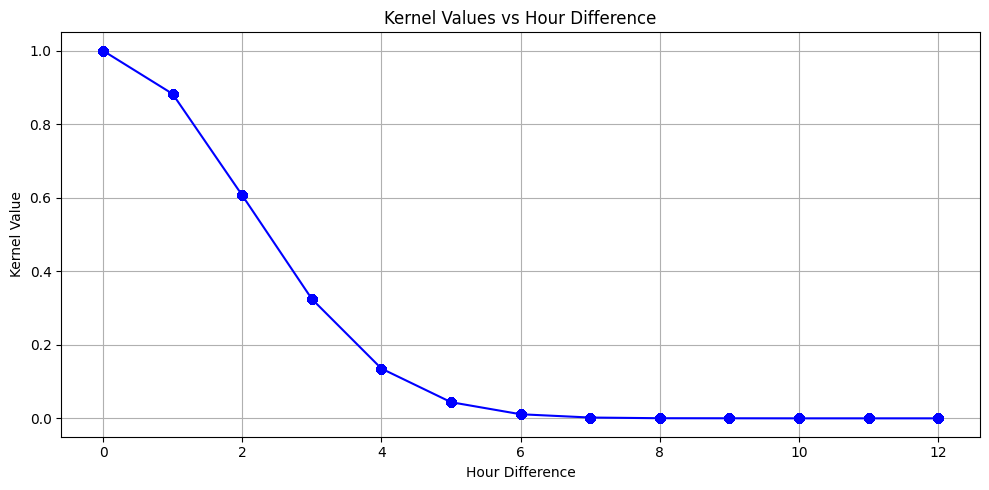

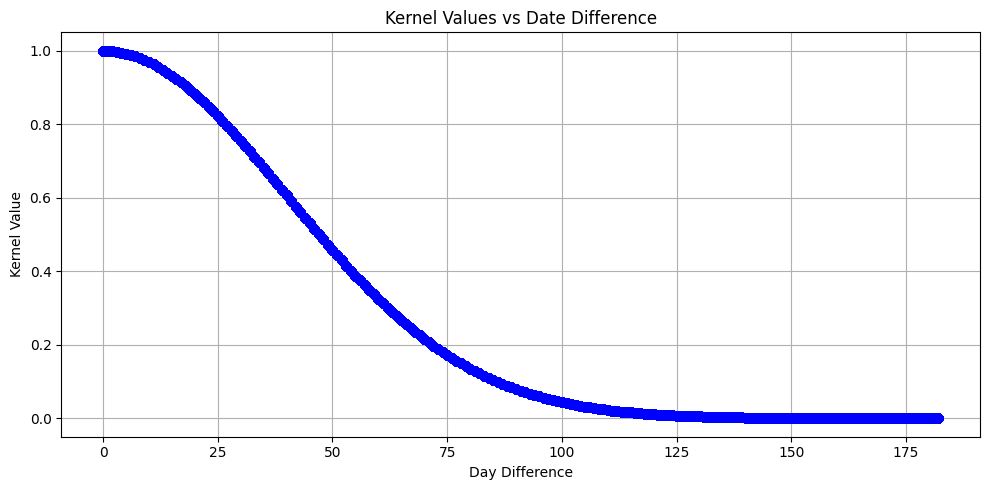

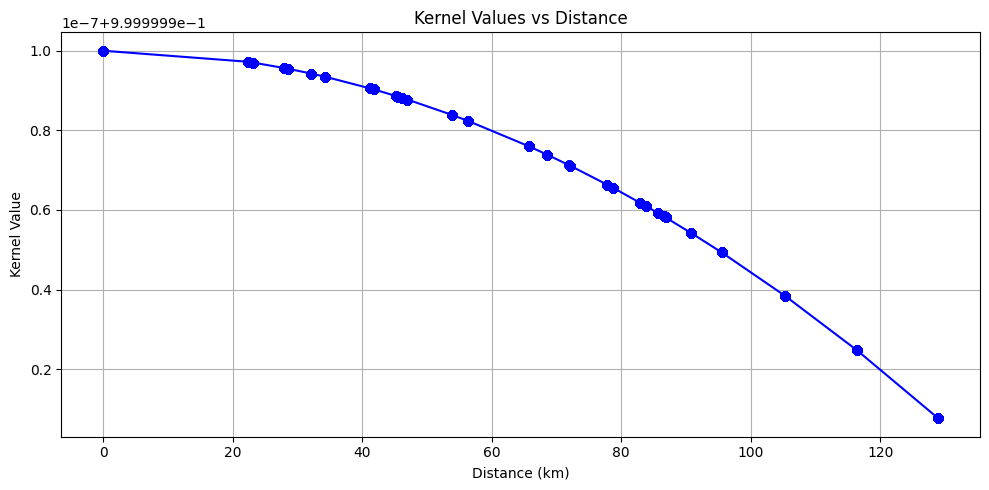

In [4]:

def plot_kernel_from_txt(file_path, x_label, title):
    data = []

    # Read and parse the file
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("(") and line.endswith(")"):
                val = line[1:-1].split(",")
                try:
                    x_val = float(val[0])
                    y_val = float(val[1])
                    data.append((x_val, y_val))
                except:
                    continue  # skip malformed lines

    # Sort data by x
    data.sort()

    # Split into x and y
    x = [item[0] for item in data]
    y = [item[1] for item in data]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, linestyle='-', marker='o', color='blue')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel("Kernel Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_kernel_from_txt("time_and_kernel/result.txt", "Hour Difference", "Kernel Values vs Hour Difference")
plot_kernel_from_txt("date_and_kernel/result.txt", "Day Difference", "Kernel Values vs Date Difference")
plot_kernel_from_txt("distance_and_kernel/result.txt", "Distance (km)", "Kernel Values vs Distance")

Predicted temperatures from 4 am to 24 pm with the time interval to be 2 hours in a day in 2013-07-04 with latitude 58.4274 and longitude 14.826 for additive and product kernel are plotted as the below. 

The multiplication method gives generally higher temperature and shows significantly large variation than the summation method. The temperature from multiplication method peaks at 17.2 degree at 12 and bottoms at 11.2 at 0, comparing to a flatten curve (7-8 degree) from the summation method. 

The reason for that the summation method has a flatter curve is that it is less sensitive to smaller kernel values. One data from station can still be somehow significant even if one of the three factors (distance, day and time) has a quite low k value, resulting smoother prediction results. While the multiplication highlight the data has close k distance to all three factors and any of further distance among those factors will be neglectable, which will lead to a more sharp curve. 

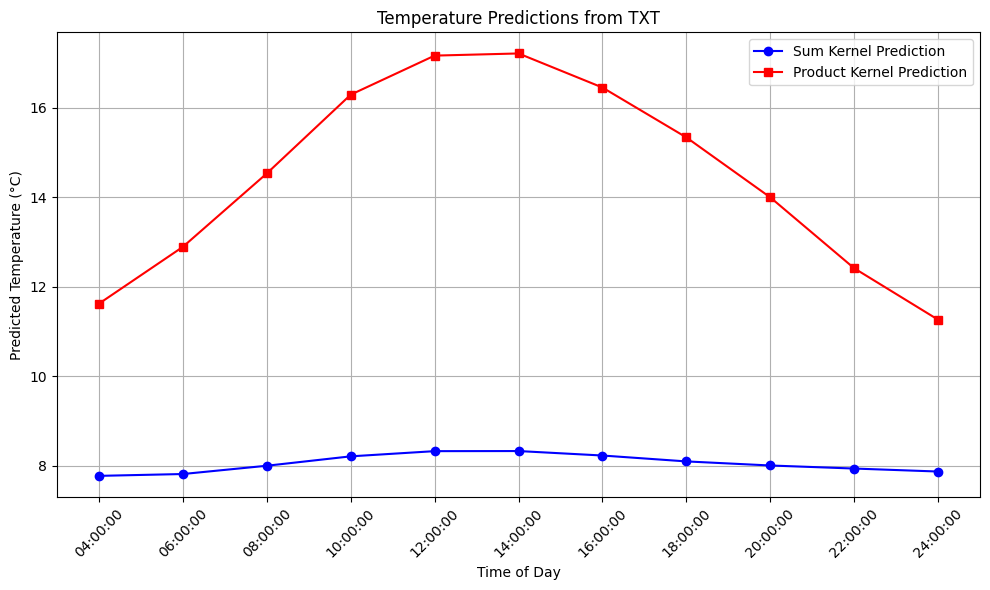

In [ ]:
# load txt 
file_path = "predictions_all_times/result.txt"
data = []

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for line_num, line in enumerate(f, 1):
        line = line.strip()
        
        line = ''.join(ch for ch in line if ch.isprintable())
        if line.startswith("(") and line.endswith(")"):
            try:
                parsed = ast.literal_eval(line)
                if isinstance(parsed, tuple) and len(parsed) == 3:
                    data.append(parsed)
                else:
                    print(f"Line {line_num} skipped: Not a 3-element tuple.")
            except Exception as e:
                print(f"Line {line_num} skipped due to parsing error: {e}")

# quit if there is no valid data
if not data:
    print("No valid data parsed.")
else:
    # reverse the data series
    data = list(reversed(data))

    # split the data
    times = [t for t, _, _ in data]
    pred_sum = [s for _, s, _ in data]
    pred_mult = [m for _, _, m in data]

    # plot
    plt.figure(figsize=(10, 6))
    plt.plot(times, pred_sum, marker='o', label='Sum Kernel Prediction', color='blue')
    plt.plot(times, pred_mult, marker='s', label='Product Kernel Prediction', color='red')

    plt.title("Temperature Predictions from TXT")
    plt.xlabel("Time of Day")
    plt.ylabel("Predicted Temperature (°C)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


<font size="5">Codes</font>


In [ ]:
from __future__ import division
from math import radians, cos, sin, asin, sqrt, exp
from datetime import datetime
from pyspark import SparkContext


sc = SparkContext(appName="lab_kernel")
def haversine(lon1, lat1, lon2, lat2):
        ### Calculate the great circle distance between two points
        ### on the earth (specified in decimal degrees)

        ### convert decimal degrees to radians
        lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
        # haversine formula
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * asin(sqrt(a))
        km = 6367 * c
        return km   


def gaussian_kernel(x, y, h):
    return exp(- ((x - y) ** 2) / (2 * h ** 2))

def day_of_year(y, m, d):
    return datetime(y, m, d).timetuple().tm_yday


### self defined parameters
### the location to be predicted

h_distance = 300000 # Up to you
h_date = 40 # Up to you
h_time = 2 # Up to you

# the location, time to be predicted
a = 58.4274 # latitude , Up to you 
b = 14.826 # longitude, Up to you

date = "2013-07-04" # Up to you
year, month, day = map(int, date.split("-"))
target_date = (year, month, day)

### Load the data

stations = sc.textFile("BDA/input/stations-Ostergotland.csv")
temps = sc.textFile("BDA/input/temperature-readings.csv")


# map the station to a tuple
station_lines = stations.map(lambda line: line.split(";"))

#(key, values)
# (key = station, (latitude, longitude))
statReadingsRow = station_lines.map(lambda p:  (p[0],(float(p[3]),float(p[4])))).collectAsMap()

# broadcast and collects the RDD to the driver as a Python dictionary
station_broadcast = sc.broadcast(statReadingsRow)


# map the temp to a tuple
Templines = temps.map(lambda line: line.split(";"))

# (station, year, month, date, time, temperature)
tempReadingsRow = Templines.map(lambda p: ( p[0], int(p[1].split("-")[0]), int(p[1].split("-")[1]), int(p[1].split("-")[2]), int(p[2].split(":")[0]),float(p[3])))

# filter the stations with temperature information in ostergotland
temp_data = tempReadingsRow.filter (
    lambda x: x[0] in station_broadcast.value.keys())

# filter out the temp after defined date
temp_data = temp_data.filter (
    lambda x: (x[1], x[2], x[3]) < (target_date))

# map the station to a tuple
temp_data = temp_data.map(lambda p: ( p[0],station_broadcast.value[p[0]][0], station_broadcast.value[p[0]][1], p[1], p[2], p[3], p[4], p[5]))\
.cache() 
# (station, latitude, longitude, year, month, date, time, temperature)

# sample from the data 
temp_data = temp_data.sample(False, 0.1)


### kernel prediction
all_predictions = []

for target_time in ["24:00:00", "22:00:00", "20:00:00", "18:00:00", "16:00:00", "14:00:00",
"12:00:00", "10:00:00", "08:00:00", "06:00:00", "04:00:00"]:
    target_hour = int(target_time.split(":")[0]) % 24  # convert to 24-hour format
    def compute_weighted_temp(record):
        _, lat, lon, year, month, day, hour_obs, temp = record
        
        #space kernel
        d_space = haversine(lon, lat, b, a)
        k_space = gaussian_kernel(0, d_space, h_distance)

        #date kernel
        target_day= day_of_year(*target_date) # days since 1st Jan 1970
        current_day = day_of_year(year, month, day) 
        d_date = min(abs(current_day - target_day), 365 - abs(current_day - target_day))  #recurrent year
        k_date = gaussian_kernel(0, d_date, h_date)

        # time kernel
        d_time = min(abs(hour_obs - target_hour), 24 - abs(hour_obs - target_hour))  # handle 23 vs 1
        k_time = gaussian_kernel(0, d_time, h_time)
    
        weight_sum = k_space + k_date + k_time  
        weight_mult = k_space * k_date * k_time  # use product instead for Q2

        return ((d_space,k_space), (d_date, k_date), (d_time, k_time), (weight_sum * temp, weight_sum), (weight_mult * temp, weight_mult))
    
    results = temp_data.map(compute_weighted_temp)
    #reduce part
    # reduce to get the sum of the weights
    pred_sum = results.map(lambda x: x[3]).reduce(lambda a, b: (a[0]+b[0], a[1]+b[1]))
    prediction_sum = pred_sum[0] / pred_sum[1] if pred_sum[1] != 0 else None
    


    # reduce to get the mult of the weights
    pred_mult = results.map(lambda x: x[4]).reduce(lambda a, b: (a[0]+b[0], a[1]+b[1]))
    prediction_mult = pred_mult[0] / pred_mult[1] if pred_mult[1] != 0 else None

    #save the prediction for each time
    all_predictions.append((target_time, prediction_sum, prediction_mult))

    #data part for visualization
    if target_time == "24:00:00": # save only the data for this time
        results.map(lambda x: x[0]).saveAsTextFile("BDA/output/distance_and_kernel")
        results.map(lambda x: x[1]).saveAsTextFile("BDA/output/date_and_kernel")
        results.map(lambda x: x[2]).saveAsTextFile("BDA/output/time_and_kernel")


sc.parallelize(all_predictions).saveAsTextFile("BDA/output/predictions_all_times")



